In [59]:
#https://github.com/sunnysavita10/yt-live-crash-course/blob/main/notebook/test.ipynb
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
#below line of code will be used to ignore error 
import warnings
warnings.filterwarnings("ignore", message="Core Pydantic V1 functionality isn't compatible")

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("Missing API key")

# ✅ Set env for LangChain
os.environ["OPENAI_API_KEY"] = OPENROUTER_API_KEY
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

chat_llm = ChatOpenAI(
    model="openai/gpt-3.5-turbo"
)

response = chat_llm.invoke("Hello, how are you?")
print(response.content)

Hello! I'm just a computer program, so I don't have feelings, but I'm here to help you. How can I assist you today?


In [60]:
from typing_extensions import TypedDict, Annotated
import operator

In [61]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [62]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [63]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [64]:
["hi"]

['hi']

In [65]:
["hi","how are you?"]

['hi', 'how are you?']

In [66]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [67]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [68]:
from langgraph.graph import StateGraph

In [69]:
builder = StateGraph(GraphState)

In [70]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [71]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [72]:
app = builder.compile()

In [73]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [74]:
from IPython.display import Image, display

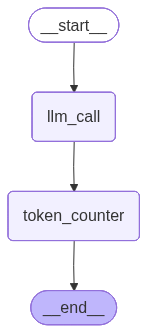

In [75]:
display(Image(app.get_graph().draw_mermaid_png()))

In [76]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [77]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Sunny! It's nice to connect with you today. I hope you are doing well and enjoying your day. It's always a pleasure to chat with new people and learn more about them. How are you feeling today? Let's have a nice conversation and get to know each other better.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 18, 'total_tokens': 77, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 9.75e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 9.75e-05, 'upstream_inference_prompt_cost': 9e-06, 'upstream_inference_completions_cost': 8.85e-

In [78]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Sunny. Say hello in detail.
AIMessage : Hello Sunny! It's nice to connect with you today. I hope you are doing well and enjoying your day. It's always a pleasure to chat with new people and learn more about them. How are you feeling today? Let's have a nice conversation and get to know each other better.
AIMessage : Total token number in the generated answer (word count) is 50


In [79]:
chat_llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001C115906FD0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C115907250>, root_client=<openai.OpenAI object at 0x000001C115904A50>, root_async_client=<openai.AsyncOpenAI object at 0x000001C115906E90>, model_name='openai/gpt-3.5-turbo', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [80]:
#tool calling .. calling wiki 
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [81]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [82]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [83]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence, commonly known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased'

In [84]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [85]:
TAVILY_API_KEY

'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'

In [86]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [87]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': '#### Some Final Thoughts\n\nA soft job market for graduates is nothing new for universities, but it certainly will be new for members of the Class of 2026. So, these students deserve our very best in helping them secure that first job. That said, every university should also be revisiting the way they think about and prepare their students for a successful career. It’s not only the right thing to do, in an environment where tuition revenue will become increasingly important, delivering career-ready graduates may well be the ticket to keeping the doors open…\n\n#### What’s Next? [...] That said, some are more pessimistic and a recent Wall Street Journal article called the current job market ‘fragile’, pointing out firms have plans to grow without hiring. Hopefully the NACE/Economist tak

In [88]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [89]:
search.invoke("what is the latest update on iphone17 release?")

'Anupdateddisplay engine, ISP, and Apple Neural Engine power features like Apple Intelligence andthelatest-generation Photographic Styles.September 9, 2025. PRESSRELEASE. Apple debutsiPhone17. iPhone17releasedate. New iPhone models for 2025 were unveiled on Tuesday, September 9, 2025. Pre-orders started on Friday, September 12, 2025, with orders to start being delivered on September 19, 2025. FastupdateiPhone 7/7p/6/6p (All iOS) to iOS16 https://bit.ly/3Qc0DFe (it also can Repair 150+ iOS/iPadOS/tvOS system problems like stuck on Apple logo... Today Applereleasedtwo newupdatesfor iPhone users to choose from. iOS 18.7isthelatestupdateto the current iPhone software that’s been available since last fall. iOS 26isthebrand new OS version that’s packed with new features. NewiPhone17Pro Details: Brighter Display, Best Battery Life, and More.iPhone17releasedate: Here’s when Apple’s new flagship will arrive.'

In [ ]:
# bingsearch, googleserperapi try this tools 

In [90]:
from langchain_community.tools import YouTubeSearchTool

In [91]:
tool=YouTubeSearchTool()

In [92]:
tool.name

'youtube_search'

In [93]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [94]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=LZzq1zSL1bs&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [95]:
tool.run("sunny savita")

"['https://www.youtube.com/watch?v=ENzZuvahKwc&pp=ygUMc3Vubnkgc2F2aXRh0gcJCdMKAYcqIYzv', 'https://www.youtube.com/watch?v=ImbmSEPo7qI&pp=ygUMc3Vubnkgc2F2aXRh']"

In [96]:
def multiply(a:int,b:int) -> int:
    return a*b

In [97]:
multiply(10,20)

200